#Tugas Besar II4013 Data Analytics
Kevin Azra - 18223029

Persada Ramiiza Abyudaya - 18223033

Inggried Amelia Deswanty - 18223035

Muhammad Aqmar Fayyaz Zakaria - 18223043

Velicia Christina Gabriel - 18223085

In [1]:
import pandas as pd
import numpy as np
import gdown
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import MinMaxScaler, StandardScaler, OneHotEncoder

## **Data Loading**

**OpenAQ**

In [2]:
df_openaq = pd.read_csv('/content/openaq.global_air_quality.csv')
display(df_openaq.head())

,location,city,country,pollutant,value,timestamp,unit,source_name,latitude,longitude,averaged_over_in_hours,location_geom
0,"Warszawa, al. Niepodległości",Warszawa,PL,bc,1.18400,2022-05-07 02:00:00.000000 UTC,µg/m³,GIOS,1.0,52.219298,21.004724,POINT(52.219298 1)
1,"Bielsko-Biała, ul. Kossak-Szczuckiej",Bielsko-Biała,PL,bc,0.95040,2022-05-09 01:00:00.000000 UTC,µg/m³,GIOS,1.0,49.813464,19.027318,POINT(49.813464 1)
2,"Zamość, ul. Hrubieszowska",Zamość,PL,bc,0.11000,2022-05-22 02:00:00.000000 UTC,µg/m³,GIOS,1.0,50.716628,23.290247,POINT(50.716628 1)
3,Gorzów Wlkp. ul. Kosynierów Gdyńskich,Gorzów Wielkopolski,PL,bc,0.03240,2022-05-06 14:00:00.000000 UTC,µg/m³,GIOS,1.0,52.738214,15.228667,POINT(52.738214 1)
4,"Szczecinek, ul. Przemysłowa",Szczecinek,PL,bc,1.01089,2022-05-12 08:00:00.000000 UTC,µg/m³,GIOS,1.0,53.698902,16.704556,POINT(53.698902 1)


In [3]:
openaq_shape = df_openaq.shape
print(openaq_shape)

(57815, 12)


**Global Air**

In [4]:
df_global = pd.read_csv('/content/pollution.csv')
display(df_global.head())

,Country,City,AQI Value,AQI Category,CO AQI Value,CO AQI Category,Ozone AQI Value,Ozone AQI Category,NO2 AQI Value,NO2 AQI Category,PM2.5 AQI Value,PM2.5 AQI Category
0,Russian Federation,Praskoveya,51,Moderate,1,Good,36,Good,0,Good,51,Moderate
1,Brazil,Presidente Dutra,41,Good,1,Good,5,Good,1,Good,41,Good
2,Italy,Priolo Gargallo,66,Moderate,1,Good,39,Good,2,Good,66,Moderate
3,Poland,Przasnysz,34,Good,1,Good,34,Good,0,Good,20,Good
4,France,Punaauia,22,Good,0,Good,22,Good,0,Good,6,Good


In [5]:
global_shape = df_global.shape
print(global_shape)

(23463, 12)


## **Merge Dataset**

In [6]:
country_code_map = {
    'AU': 'Australia',
    'BR': 'Brazil',
    'CA': 'Canada',
    'CN': 'China',
    'FR': 'France',
    'DE': 'Germany',
    'IN': 'India',
    'MX': 'Mexico',
    'RU': 'Russia',
    'ZA': 'South Africa',
    'ES': 'Spain',
    'TH': 'Thailand',
    'TR': 'Turkey',
    'AE': 'UAE',
    'GB': 'UK',
    'US': 'USA',
    'AD': 'Andorra',
    'AR': 'Argentina',
    'AT': 'Austria',
    'BA': 'Bosnia and Herzegovina',
    'BE': 'Belgium',
    'BG': 'Bulgaria',
    'CH': 'Switzerland',
    'CL': 'Chile',
    'CO': 'Colombia',
    'CW': 'Curacao',
    'CY': 'Cyprus',
    'CZ': 'Czech Republic',
    'DK': 'Denmark',
    'EC': 'Ecuador',
    'EE': 'Estonia',
    'FI': 'Finland',
    'GR': 'Greece',
    'GT': 'Guatemala',
    'HK': 'Hong Kong',
    'HR': 'Croatia',
    'HU': 'Hungary',
    'IE': 'Ireland',
    'IL': 'Israel',
    'IT': 'Italy',
    'LT': 'Lithuania',
    'LU': 'Luxembourg',
    'LV': 'Latvia',
    'ME': 'Montenegro',
    'MK': 'North Macedonia',
    'MT': 'Malta',
    'NL': 'Netherlands',
    'NO': 'Norway',
    'NP': 'Nepal',
    'PE': 'Peru',
    'PL': 'Poland',
    'PT': 'Portugal',
    'QA': 'Qatar',
    'RO': 'Romania',
    'RS': 'Serbia',
    'SE': 'Sweden',
    'SK': 'Slovakia',
    'TW': 'Taiwan',
    'UZ': 'Uzbekistan',
    'XK': 'Kosovo',
}

In [7]:
df_openaq['country_name'] = df_openaq['country'].map(country_code_map)
unmapped = df_openaq[df_openaq['country_name'].isna()]['country'].unique()

if len(unmapped) > 0:
  print(f"Kode negara yang unmapped: {unmapped}")
else:
  print("Semua negara mapped")

Semua negara mapped


In [8]:
df_global_standard = df_global.rename(columns={'Country': 'country'})

In [9]:
df_openaq['city_clean'] = df_openaq['city'].str.strip().str.lower()
df_global_standard['city_clean'] = df_global_standard['City'].str.strip().str.lower()

In [10]:
df_merged = pd.merge(
    df_global_standard,
    df_openaq,
    left_on=['city_clean', 'country'],
    right_on=['city_clean', 'country_name'],
    how='inner',
    suffixes=('_global', '_openaq')
)

#sisakan satu kolom country dan city
df_merged.drop(columns=['country_name', 'city_clean', 'city', 'country_openaq'], inplace=True)
df_merged.rename(columns={'country_global': 'country'}, inplace=True)
df_merged.rename(columns={'City': 'city'}, inplace=True)

In [11]:
display(df_merged)

,country,city,AQI Value,AQI Category,CO AQI Value,CO AQI Category,Ozone AQI Value,Ozone AQI Category,NO2 AQI Value,NO2 AQI Category,...,location,pollutant,value,timestamp,unit,source_name,latitude,longitude,averaged_over_in_hours,location_geom
0,India,Rajgir,154,Unhealthy,3,Good,100,Unhealthy for Sensitive Groups,2,Good,...,"Dangi Tola, Rajgir - BSPCB",co,960.000,2022-05-05 23:45:00.000000 UTC,µg/m³,caaqm,0.25,25.032800,85.419480,POINT(25.0328 0.25)
1,India,Rajgir,154,Unhealthy,3,Good,100,Unhealthy for Sensitive Groups,2,Good,...,"Dangi Tola, Rajgir - BSPCB",co,1200.000,2022-05-18 22:45:00.000000 UTC,µg/m³,caaqm,0.25,25.032800,85.419480,POINT(25.0328 0.25)
2,India,Rajgir,154,Unhealthy,3,Good,100,Unhealthy for Sensitive Groups,2,Good,...,"Dangi Tola, Rajgir - BSPCB",co,350.000,2022-05-09 05:45:00.000000 UTC,µg/m³,caaqm,0.25,25.032800,85.419480,POINT(25.0328 0.25)
3,India,Rajgir,154,Unhealthy,3,Good,100,Unhealthy for Sensitive Groups,2,Good,...,"Dangi Tola, Rajgir - BSPCB",co,1030.000,2022-05-07 21:45:00.000000 UTC,µg/m³,caaqm,0.25,25.032800,85.419480,POINT(25.0328 0.25)
4,India,Rajgir,154,Unhealthy,3,Good,100,Unhealthy for Sensitive Groups,2,Good,...,"Dangi Tola, Rajgir - BSPCB",co,1350.000,2022-05-24 09:45:00.000000 UTC,µg/m³,caaqm,0.25,25.032800,85.419480,POINT(25.0328 0.25)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14519,Thailand,Nakhon Si Thammarat,58,Moderate,1,Good,32,Good,0,Good,...,Elderly Health Rehabilitation Center,o3,0.011,2022-05-10 07:00:00.000000 UTC,ppm,Air4Thai,8.00,8.426923,99.961469,POINT(8.426923 8)
14520,Thailand,Nakhon Si Thammarat,58,Moderate,1,Good,32,Good,0,Good,...,Elderly Health Rehabilitation Center,co,0.250,2022-05-08 10:00:00.000000 UTC,ppm,Air4Thai,8.00,8.426923,99.961469,POINT(8.426923 8)
14521,Thailand,Nakhon Si Thammarat,58,Moderate,1,Good,32,Good,0,Good,...,Elderly Health Rehabilitation Center,co,0.220,2022-05-12 08:00:00.000000 UTC,ppm,Air4Thai,8.00,8.426923,99.961469,POINT(8.426923 8)
14522,Thailand,Nakhon Si Thammarat,58,Moderate,1,Good,32,Good,0,Good,...,Elderly Health Rehabilitation Center,co,0.220,2022-05-18 09:00:00.000000 UTC,ppm,Air4Thai,8.00,8.426923,99.961469,POINT(8.426923 8)


## **Data Preprocessing**

### **EDA Awal untuk Data Cleansing**

In [12]:
print(df_merged.dtypes)

country                    object
city                       object
AQI Value                   int64
AQI Category               object
CO AQI Value                int64
CO AQI Category            object
Ozone AQI Value             int64
Ozone AQI Category         object
NO2 AQI Value               int64
NO2 AQI Category           object
PM2.5 AQI Value             int64
PM2.5 AQI Category         object
location                   object
pollutant                  object
value                     float64
timestamp                  object
unit                       object
source_name                object
latitude                  float64
longitude                 float64
averaged_over_in_hours    float64
location_geom              object
dtype: object


In [13]:
df_merged['timestamp'] = pd.to_datetime(df_merged['timestamp'])

In [14]:
all_columns = df_merged.columns
print(all_columns)

Index(['country', 'city', 'AQI Value', 'AQI Category', 'CO AQI Value',
       'CO AQI Category', 'Ozone AQI Value', 'Ozone AQI Category',
       'NO2 AQI Value', 'NO2 AQI Category', 'PM2.5 AQI Value',
       'PM2.5 AQI Category', 'location', 'pollutant', 'value', 'timestamp',
       'unit', 'source_name', 'latitude', 'longitude',
       'averaged_over_in_hours', 'location_geom'],
      dtype='object')


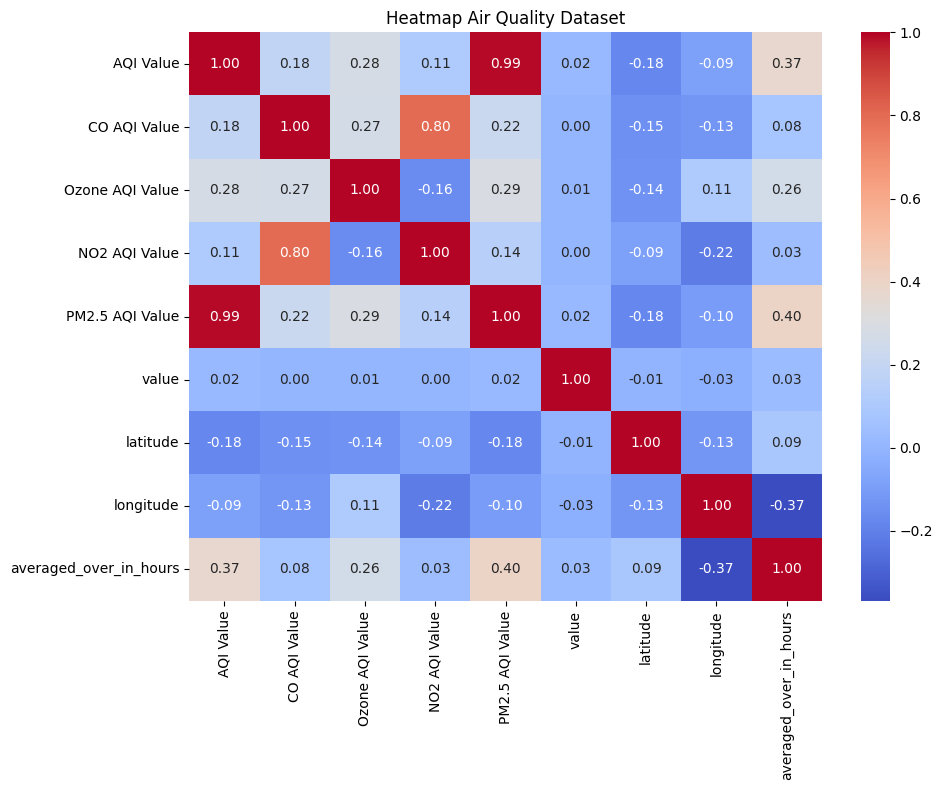

In [15]:
numeric_cols = df_merged.select_dtypes(include=['float64', 'int64'])
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Heatmap Air Quality Dataset')
plt.tight_layout()
plt.show()

In [16]:
print(f"Jumlah data duplikat: {df_merged.duplicated().sum()}")

Jumlah data duplikat: 0


In [17]:
missing_value = df_merged.isnull().sum()
print(f"Jumlah missing value: {missing_value}")
print("\nMissing value tidak ada karena menggunakan metode Inner Join saat merge dataset")

Jumlah missing value: country                   0
city                      0
AQI Value                 0
AQI Category              0
CO AQI Value              0
CO AQI Category           0
Ozone AQI Value           0
Ozone AQI Category        0
NO2 AQI Value             0
NO2 AQI Category          0
PM2.5 AQI Value           0
PM2.5 AQI Category        0
location                  0
pollutant                 0
value                     0
timestamp                 0
unit                      0
source_name               0
latitude                  0
longitude                 0
averaged_over_in_hours    0
location_geom             0
dtype: int64

Missing value tidak ada karena menggunakan metode Inner Join saat merge dataset


In [18]:
def check_outliers(df, dataset_name):
    numeric_cols = df.select_dtypes(include=[np.number]).columns

    for col in numeric_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        percentage = (len(outliers) / len(df)) * 100

        print(f" - Kolom '{col}': {len(outliers)} outliers ({percentage:.2f}%)")

check_outliers(df_merged, "Dataset Merged")

 - Kolom 'AQI Value': 1658 outliers (11.42%)
 - Kolom 'CO AQI Value': 5889 outliers (40.55%)
 - Kolom 'Ozone AQI Value': 1561 outliers (10.75%)
 - Kolom 'NO2 AQI Value': 1707 outliers (11.75%)
 - Kolom 'PM2.5 AQI Value': 1441 outliers (9.92%)
 - Kolom 'value': 1176 outliers (8.10%)
 - Kolom 'latitude': 1070 outliers (7.37%)
 - Kolom 'longitude': 891 outliers (6.13%)
 - Kolom 'averaged_over_in_hours': 292 outliers (2.01%)


In [19]:
categorical_col = df_merged.select_dtypes(include=['object', 'category']).columns
print(categorical_col)

Index(['country', 'city', 'AQI Category', 'CO AQI Category',
       'Ozone AQI Category', 'NO2 AQI Category', 'PM2.5 AQI Category',
       'location', 'pollutant', 'unit', 'source_name', 'location_geom'],
      dtype='object')


### **Data Cleansing and Preprocessing**

In [20]:
# drop kolom-kolom yang tidak relevan
df_merged.drop(columns=['source_name', 'location_geom', 'location'], inplace=True)

### **Memisahkan Format Timestamp**

In [21]:
df_merged['timestamp'] = pd.to_datetime(df_merged['timestamp'])
df_merged['hour'] = df_merged['timestamp'].dt.hour
df_merged['day_of_week'] = df_merged['timestamp'].dt.dayofweek
df_merged['month'] = df_merged['timestamp'].dt.month

df_merged.drop(columns=['timestamp'], inplace=True)

### **Encoding untuk Kolom Kategorikal**

In [22]:
categorical_cols_to_encode = [
    'CO AQI Category', 'Ozone AQI Category',
    'NO2 AQI Category', 'PM2.5 AQI Category', 'pollutant'
]

df_merged = pd.get_dummies(df_merged, columns=categorical_cols_to_encode, drop_first=False)

In [23]:
print(f"Jumlah negara unik: {df_merged['country'].nunique()}")
print(f"Jumlah kota unik: {df_merged['city'].nunique()}")

Jumlah negara unik: 33
Jumlah kota unik: 386


In [24]:
#jumlah negara dan kota terlalu banyak sehingga dilakukan Frequency Encoding
freq_city = df_merged['city'].value_counts(normalize=True).to_dict()
df_merged['city'] = df_merged['city'].map(freq_city)

freq_map = df_merged['country'].value_counts(normalize=True).to_dict()
df_merged['country'] = df_merged['country'].map(freq_map)

### **Konversi Kolom 'value' dari µg/m³ ke ppm**
$$ \text{ppm} = \frac{\mu g/m^3 \times 24.45}{\text{Berat Molekul (BM)} \times 1000} $$
Daftar Berat Molekul:

*   Karbon Monoksida (CO): 28.01 g/mol
*   Ozon (O3): 48.00 g/mol
*   Black Carbon (BC/C): 12.01 g/mol

Proses ini dilakukan supaya kolom 'unit' dapat di-drop

In [25]:
def convert_ugm3_to_ppm(row):
    if row['unit'] == 'µg/m³':
        molecular_weight = 0
        if row['pollutant_co']:
            molecular_weight = 28.01
        elif row['pollutant_o3']:
            molecular_weight = 48.00
        elif row['pollutant_bc']:
            molecular_weight = 12.01

        if molecular_weight > 0:
            row['value'] = row['value'] * 24.45 / (molecular_weight * 1000)
            row['unit'] = 'ppm'
    return row

df_merged = df_merged.apply(convert_ugm3_to_ppm, axis=1)
df_merged.drop(columns=['unit'], inplace=True)

In [26]:
df_merged

,country,city,AQI Value,AQI Category,CO AQI Value,Ozone AQI Value,NO2 AQI Value,PM2.5 AQI Value,value,latitude,...,NO2 AQI Category_Good,PM2.5 AQI Category_Good,PM2.5 AQI Category_Hazardous,PM2.5 AQI Category_Moderate,PM2.5 AQI Category_Unhealthy,PM2.5 AQI Category_Unhealthy for Sensitive Groups,PM2.5 AQI Category_Very Unhealthy,pollutant_bc,pollutant_co,pollutant_o3
0,0.423299,0.002066,154,Unhealthy,3,100,2,154,0.837986,0.25,...,True,False,False,False,True,False,False,False,True,False
1,0.423299,0.002066,154,Unhealthy,3,100,2,154,1.047483,0.25,...,True,False,False,False,True,False,False,False,True,False
2,0.423299,0.002066,154,Unhealthy,3,100,2,154,0.305516,0.25,...,True,False,False,False,True,False,False,False,True,False
3,0.423299,0.002066,154,Unhealthy,3,100,2,154,0.899090,0.25,...,True,False,False,False,True,False,False,False,True,False
4,0.423299,0.002066,154,Unhealthy,3,100,2,154,1.178418,0.25,...,True,False,False,False,True,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14519,0.083310,0.002066,58,Moderate,1,32,0,58,0.011000,8.00,...,True,False,False,True,False,False,False,False,False,True
14520,0.083310,0.002066,58,Moderate,1,32,0,58,0.250000,8.00,...,True,False,False,True,False,False,False,False,True,False
14521,0.083310,0.002066,58,Moderate,1,32,0,58,0.220000,8.00,...,True,False,False,True,False,False,False,False,True,False
14522,0.083310,0.002066,58,Moderate,1,32,0,58,0.220000,8.00,...,True,False,False,True,False,False,False,False,True,False


**Feature Engineering**

In [27]:
df_merged['traffic_pollution_proxy'] = df_merged['CO AQI Value'] + df_merged['NO2 AQI Value']
df_merged

,country,city,AQI Value,AQI Category,CO AQI Value,Ozone AQI Value,NO2 AQI Value,PM2.5 AQI Value,value,latitude,...,PM2.5 AQI Category_Good,PM2.5 AQI Category_Hazardous,PM2.5 AQI Category_Moderate,PM2.5 AQI Category_Unhealthy,PM2.5 AQI Category_Unhealthy for Sensitive Groups,PM2.5 AQI Category_Very Unhealthy,pollutant_bc,pollutant_co,pollutant_o3,traffic_pollution_proxy
0,0.423299,0.002066,154,Unhealthy,3,100,2,154,0.837986,0.25,...,False,False,False,True,False,False,False,True,False,5
1,0.423299,0.002066,154,Unhealthy,3,100,2,154,1.047483,0.25,...,False,False,False,True,False,False,False,True,False,5
2,0.423299,0.002066,154,Unhealthy,3,100,2,154,0.305516,0.25,...,False,False,False,True,False,False,False,True,False,5
3,0.423299,0.002066,154,Unhealthy,3,100,2,154,0.899090,0.25,...,False,False,False,True,False,False,False,True,False,5
4,0.423299,0.002066,154,Unhealthy,3,100,2,154,1.178418,0.25,...,False,False,False,True,False,False,False,True,False,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14519,0.083310,0.002066,58,Moderate,1,32,0,58,0.011000,8.00,...,False,False,True,False,False,False,False,False,True,1
14520,0.083310,0.002066,58,Moderate,1,32,0,58,0.250000,8.00,...,False,False,True,False,False,False,False,True,False,1
14521,0.083310,0.002066,58,Moderate,1,32,0,58,0.220000,8.00,...,False,False,True,False,False,False,False,True,False,1
14522,0.083310,0.002066,58,Moderate,1,32,0,58,0.220000,8.00,...,False,False,True,False,False,False,False,True,False,1


**Save Dataset Bersih**

In [28]:
df_merged.to_csv('cleaned_dataset.csv')

# **Eksplorasi Data**

**Load Dataset**

In [29]:
df = pd.read_csv('cleaned_dataset.csv')
print(f"Dataset berhasil dimuat.")
print(f"Ukuran dataset  : {df.shape[0]:,} baris × {df.shape[1]} kolom")
print(f"\nKolom yang tersedia:")
print(df.columns.tolist())
print(f"\nPreview data:")
df.head()

Dataset berhasil dimuat.
Ukuran dataset  : 14,524 baris × 33 kolom

Kolom yang tersedia:
['Unnamed: 0', 'country', 'city', 'AQI Value', 'AQI Category', 'CO AQI Value', 'Ozone AQI Value', 'NO2 AQI Value', 'PM2.5 AQI Value', 'value', 'latitude', 'longitude', 'averaged_over_in_hours', 'hour', 'day_of_week', 'month', 'CO AQI Category_Good', 'Ozone AQI Category_Good', 'Ozone AQI Category_Moderate', 'Ozone AQI Category_Unhealthy', 'Ozone AQI Category_Unhealthy for Sensitive Groups', 'Ozone AQI Category_Very Unhealthy', 'NO2 AQI Category_Good', 'PM2.5 AQI Category_Good', 'PM2.5 AQI Category_Hazardous', 'PM2.5 AQI Category_Moderate', 'PM2.5 AQI Category_Unhealthy', 'PM2.5 AQI Category_Unhealthy for Sensitive Groups', 'PM2.5 AQI Category_Very Unhealthy', 'pollutant_bc', 'pollutant_co', 'pollutant_o3', 'traffic_pollution_proxy']

Preview data:


,Unnamed: 0,country,city,AQI Value,AQI Category,CO AQI Value,Ozone AQI Value,NO2 AQI Value,PM2.5 AQI Value,value,...,PM2.5 AQI Category_Good,PM2.5 AQI Category_Hazardous,PM2.5 AQI Category_Moderate,PM2.5 AQI Category_Unhealthy,PM2.5 AQI Category_Unhealthy for Sensitive Groups,PM2.5 AQI Category_Very Unhealthy,pollutant_bc,pollutant_co,pollutant_o3,traffic_pollution_proxy
0,0,0.423299,0.002066,154,Unhealthy,3,100,2,154,0.837986,...,False,False,False,True,False,False,False,True,False,5
1,1,0.423299,0.002066,154,Unhealthy,3,100,2,154,1.047483,...,False,False,False,True,False,False,False,True,False,5
2,2,0.423299,0.002066,154,Unhealthy,3,100,2,154,0.305516,...,False,False,False,True,False,False,False,True,False,5
3,3,0.423299,0.002066,154,Unhealthy,3,100,2,154,0.899090,...,False,False,False,True,False,False,False,True,False,5
4,4,0.423299,0.002066,154,Unhealthy,3,100,2,154,1.178418,...,False,False,False,True,False,False,False,True,False,5


**Statistik Deskriptif Variabel Utama**

In [30]:
print("=" * 65)
print("  STATISTIK DESKRIPTIF VARIABEL UTAMA")
print("=" * 65)

numeric_cols = ['AQI Value', 'CO AQI Value', 'Ozone AQI Value',
                'NO2 AQI Value', 'PM2.5 AQI Value', 'traffic_pollution_proxy']
desc = df[numeric_cols].describe().T
desc['median']   = df[numeric_cols].median()
desc['skewness'] = df[numeric_cols].skew()
desc['kurtosis'] = df[numeric_cols].kurtosis()
desc = desc[['count','mean','std','min','25%','median','75%','max','skewness','kurtosis']]
desc.columns = ['N','Mean','Std Dev','Min','Q1','Median','Q3','Max','Skewness','Kurtosis']
desc = desc.round(2)
print(desc.to_string())
print()

# Distribusi AQI Category
cat_order = ['Good','Moderate','Unhealthy for Sensitive Groups','Unhealthy','Very Unhealthy','Hazardous']
cat_counts = df['AQI Category'].value_counts().reindex(cat_order).dropna()
cat_pct    = (cat_counts / len(df) * 100).round(1)
cat_df = pd.DataFrame({'Frekuensi': cat_counts, 'Persentase (%)': cat_pct})
print("-" * 45)
print("  DISTRIBUSI KATEGORI AQI")
print("-" * 45)
print(cat_df.to_string())
print()

  STATISTIK DESKRIPTIF VARIABEL UTAMA
                               N    Mean  Std Dev   Min    Q1  Median     Q3    Max  Skewness  Kurtosis
AQI Value                14524.0  132.33   139.81  16.0  42.0    68.0  169.0  500.0      1.77      1.99
CO AQI Value             14524.0    1.53     1.70   0.0   1.0     1.0    1.0   13.0      2.79     10.46
Ozone AQI Value          14524.0   45.46    34.90   0.0  25.0    37.0   46.0  201.0      2.18      4.47
NO2 AQI Value            14524.0    2.57     5.02   0.0   0.0     1.0    2.0   39.0      3.78     17.10
PM2.5 AQI Value          14524.0  123.25   128.55   7.0  36.0    67.0  168.0  500.0      1.62      1.69
traffic_pollution_proxy  14524.0    4.10     6.46   0.0   1.0     2.0    4.0   52.0      3.69     16.70

---------------------------------------------
  DISTRIBUSI KATEGORI AQI
---------------------------------------------
                                Frekuensi  Persentase (%)
AQI Category                                             

**Interpretasi Statistik Deskriptif:**

• AQI Value rata-rata 132.3, std dev tinggi yaitu 139.8 menunjukkan distribusi
kualitas udara sangat beragam.

   • PM2.5 AQI Value adalah polutan dominan dengan nilai mean 123.3, korelasi 0.994 dengan AQI Value.

   • Skewness positif tinggi menunjukkan kondisi ekstrem AQI 500 yang ada dalam data

**Visualisasi 1: Distribusi AQI Value**

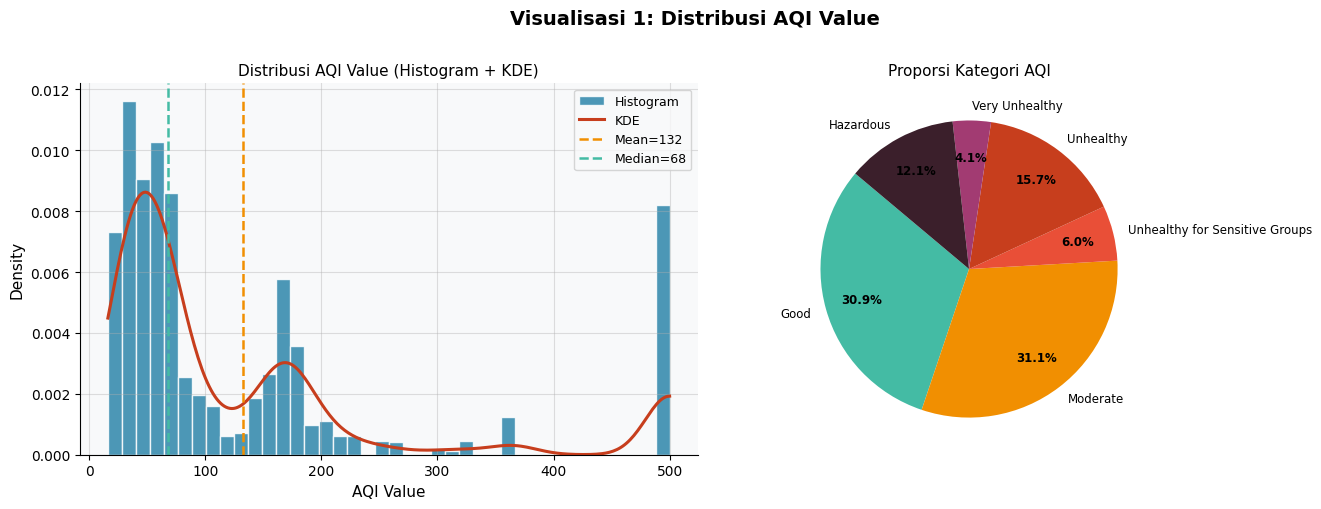

In [31]:
# Style
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#F8F9FA',
    'axes.grid': True,
    'grid.alpha': 0.4,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
})
PALETTE = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3B1F2B', '#44BBA4', '#E94F37']

cat_order = ['Good','Moderate','Unhealthy for Sensitive Groups','Unhealthy','Very Unhealthy','Hazardous']
cat_counts = df['AQI Category'].value_counts().reindex(cat_order).dropna()
colors_pie = ['#44BBA4','#F18F01','#E94F37','#C73E1D','#A23B72','#3B1F2B']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Visualisasi 1: Distribusi AQI Value', fontsize=14, fontweight='bold', y=1.01)

# Histogram + KDE
ax1 = axes[0]
ax1.hist(df['AQI Value'], bins=40, color='#2E86AB', edgecolor='white', alpha=0.85,
         density=True, label='Histogram')
kde_x = np.linspace(df['AQI Value'].min(), df['AQI Value'].max(), 300)
kde = stats.gaussian_kde(df['AQI Value'])
ax1.plot(kde_x, kde(kde_x), color='#C73E1D', linewidth=2.2, label='KDE')
ax1.axvline(df['AQI Value'].mean(),   color='#F18F01', linestyle='--', linewidth=1.8,
            label=f"Mean={df['AQI Value'].mean():.0f}")
ax1.axvline(df['AQI Value'].median(), color='#44BBA4', linestyle='--', linewidth=1.8,
            label=f"Median={df['AQI Value'].median():.0f}")
ax1.set_xlabel('AQI Value', fontsize=11)
ax1.set_ylabel('Density', fontsize=11)
ax1.set_title('Distribusi AQI Value (Histogram + KDE)', fontsize=11)
ax1.legend(fontsize=9)

# Pie AQI Category
ax2 = axes[1]
wedges, texts, autotexts = ax2.pie(
    cat_counts.values, labels=cat_counts.index,
    colors=colors_pie[:len(cat_counts)], autopct='%1.1f%%',
    startangle=140, pctdistance=0.75, textprops={'fontsize': 8.5})
for at in autotexts:
    at.set_fontweight('bold')
ax2.set_title('Proporsi Kategori AQI', fontsize=11)

plt.tight_layout()
plt.savefig('vis1_distribusi_aqi.png', dpi=150, bbox_inches='tight')
plt.show()

**INTERPRETASI VISUALISASI 1:**

Histogram menunjukkan distribusi bimodal AQI dengan puncak pertama di rentang 'Good–Moderate' dengan nilai AQI 16–100 dan puncak kedua di 'Unhealthy–Hazardous' dengan nilai AQI 150–500. Mean dengan nilai 132 lebih besar dari Median yang nilainya 68. Hal ini mengonfirmasi right-skew kuat, artinya sebagian kecil pengukuran ekstrem menarik rata-rata ke atas. Kategori Moderate dengan nilai 31.1% dan Good dengan nilai 30.9% mendominasi, tetapi Hazardous dengan nilai 12.1% merupakan hal yang serius bagi kesehatan.

**Visualisasi 2: Tren Temporal AQI Value**

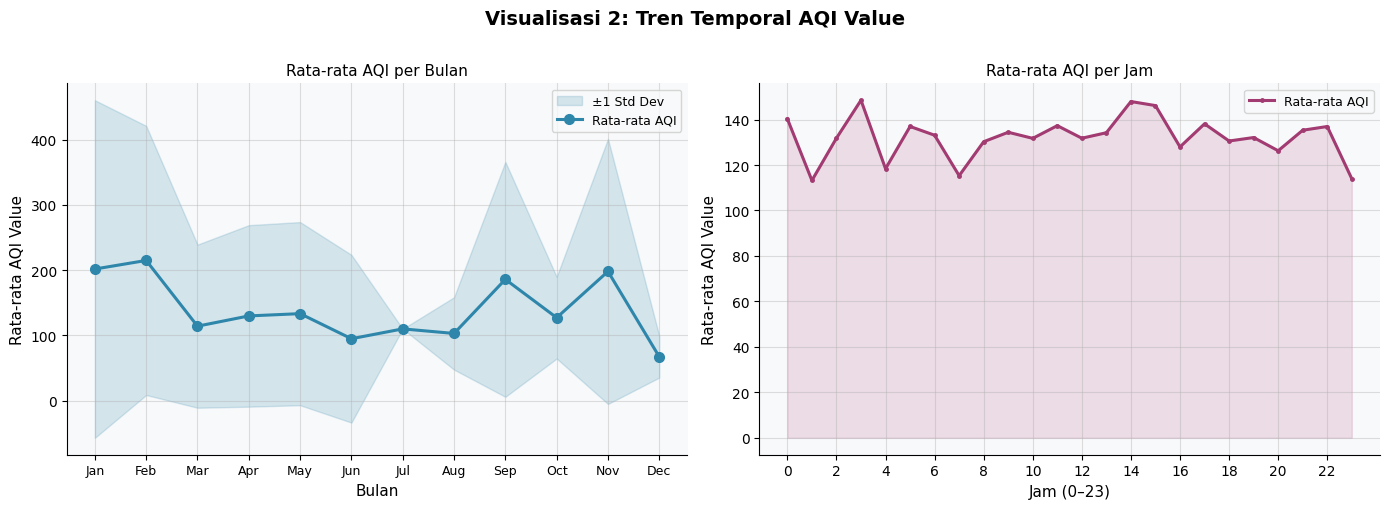

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Visualisasi 2: Tren Temporal AQI Value', fontsize=14, fontweight='bold', y=1.01)

month_agg   = df.groupby('month')['AQI Value'].agg(['mean','std']).reset_index()
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

ax1 = axes[0]
ax1.fill_between(month_agg['month'],
                  month_agg['mean'] - month_agg['std'],
                  month_agg['mean'] + month_agg['std'],
                  alpha=0.18, color='#2E86AB', label='±1 Std Dev')
ax1.plot(month_agg['month'], month_agg['mean'], marker='o', color='#2E86AB',
         linewidth=2.2, markersize=7, label='Rata-rata AQI')
ax1.set_xticks(range(1, 13))
ax1.set_xticklabels(month_labels, fontsize=9)
ax1.set_xlabel('Bulan', fontsize=11)
ax1.set_ylabel('Rata-rata AQI Value', fontsize=11)
ax1.set_title('Rata-rata AQI per Bulan', fontsize=11)
ax1.legend(fontsize=9)

hour_agg = df.groupby('hour')['AQI Value'].mean().reset_index()
ax2 = axes[1]
ax2.plot(hour_agg['hour'], hour_agg['AQI Value'], color='#A23B72',
         linewidth=2.2, marker='.', markersize=5, label='Rata-rata AQI')
ax2.fill_between(hour_agg['hour'], hour_agg['AQI Value'], alpha=0.15, color='#A23B72')
ax2.set_xticks(range(0, 24, 2))
ax2.set_xlabel('Jam (0–23)', fontsize=11)
ax2.set_ylabel('Rata-rata AQI Value', fontsize=11)
ax2.set_title('Rata-rata AQI per Jam', fontsize=11)
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig('vis2_tren_temporal.png', dpi=150, bbox_inches='tight')
plt.show()

**INTERPRETASI VISUALISASI 2:**

Tren bulanan memperlihatkan pola musiman yang jelas, yaitu AQI tertinggi terjadi pada Februari dengan nilai 214.8 dan Januari dengan nilai 201.7. Kemudian menurun tajam menjelang musim panas dari Juni–Agustus, dengan AQI 94–110. Lonjakan kembali di September dengan nilai 185.8 dan November dengan nilai 198 yang mengindikasikan pengaruh musim kemarau atau kebakaran hutan. Tren per jam relatif datar, artinya polusi lebih dipengaruhi faktor musiman atau regional daripada siklus harian.

**Visualisasi 3: Perbandingan Polutan per Kategori AQI**

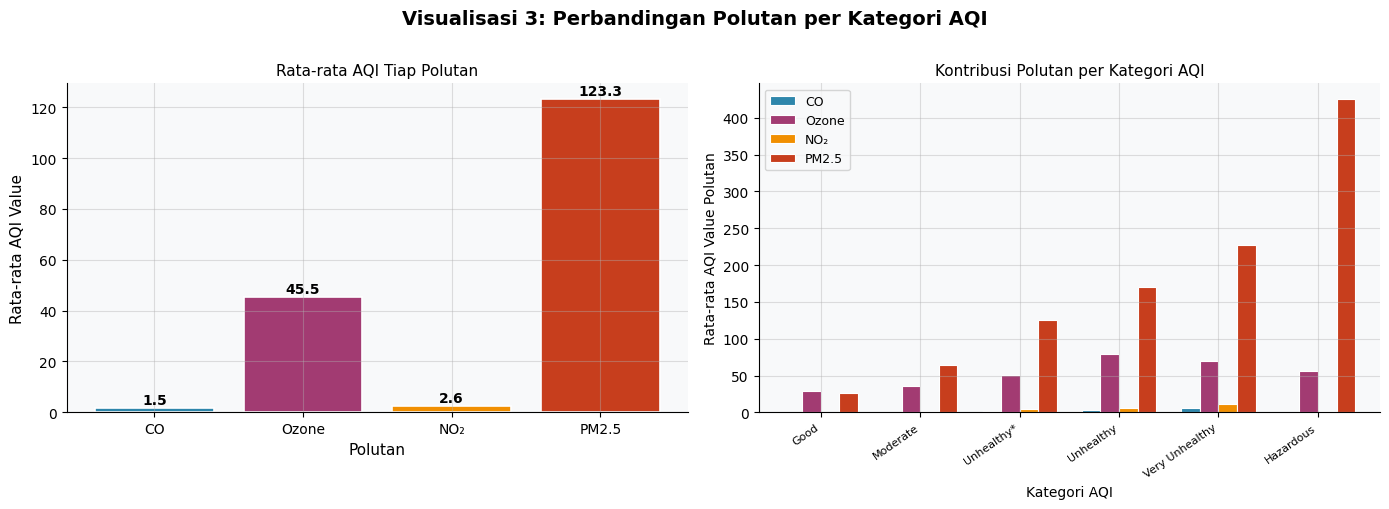

In [33]:
pollutant_cols = ['CO AQI Value', 'Ozone AQI Value', 'NO2 AQI Value', 'PM2.5 AQI Value']
poll_labels    = ['CO', 'Ozone', 'NO₂', 'PM2.5']
cat_order_plot = ['Good','Moderate','Unhealthy for Sensitive Groups',
                  'Unhealthy','Very Unhealthy','Hazardous']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Visualisasi 3: Perbandingan Polutan per Kategori AQI',
             fontsize=14, fontweight='bold', y=1.01)

ax1 = axes[0]
poll_means = df[pollutant_cols].mean()
bars = ax1.bar(poll_labels, poll_means.values, color=PALETTE[:4], edgecolor='white', linewidth=1.2)
for bar, val in zip(bars, poll_means.values):
    ax1.text(bar.get_x() + bar.get_width()/2, val + 0.5, f'{val:.1f}',
             ha='center', va='bottom', fontsize=10, fontweight='bold')
ax1.set_xlabel('Polutan', fontsize=11)
ax1.set_ylabel('Rata-rata AQI Value', fontsize=11)
ax1.set_title('Rata-rata AQI Tiap Polutan', fontsize=11)

ax2 = axes[1]
poll_cat = df[df['AQI Category'].isin(cat_order_plot)].groupby('AQI Category')[pollutant_cols].mean()
poll_cat = poll_cat.reindex(cat_order_plot)
poll_cat.columns = poll_labels
colors_pie = ['#44BBA4','#F18F01','#E94F37','#C73E1D','#A23B72','#3B1F2B']
poll_cat.plot(kind='bar', ax=ax2, color=PALETTE[:4], edgecolor='white', linewidth=0.8, width=0.75)
ax2.set_xlabel('Kategori AQI', fontsize=10)
ax2.set_ylabel('Rata-rata AQI Value Polutan', fontsize=10)
ax2.set_title('Kontribusi Polutan per Kategori AQI', fontsize=11)
ax2.set_xticklabels([c.replace(' for Sensitive Groups','*') for c in cat_order_plot],
                     rotation=35, ha='right', fontsize=8)
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig('vis3_perbandingan_polutan.png', dpi=150, bbox_inches='tight')
plt.show()

**INTERPRETASI VISUALISASI 3:**

PM2.5 mendominasi dengan rata-rata AQI 123.3, jauh melampaui Ozone yang nilainya 40.3, CO yang nilainya 1.5, dan NO₂ yang nilainya 1.6. Pada kategori Hazardous dan Very Unhealthy, PM2.5 menyumbang hampir seluruh nilai AQI keseluruhan. Hal ini mengonfirmasi bahwa partikel halus seperti PM2.5 adalah polutan utama dan harus menjadi prioritas utama dalam intervensi kebijakan kualitas udara.

**Visualisasi 4: Hubungan Antarvariabel**

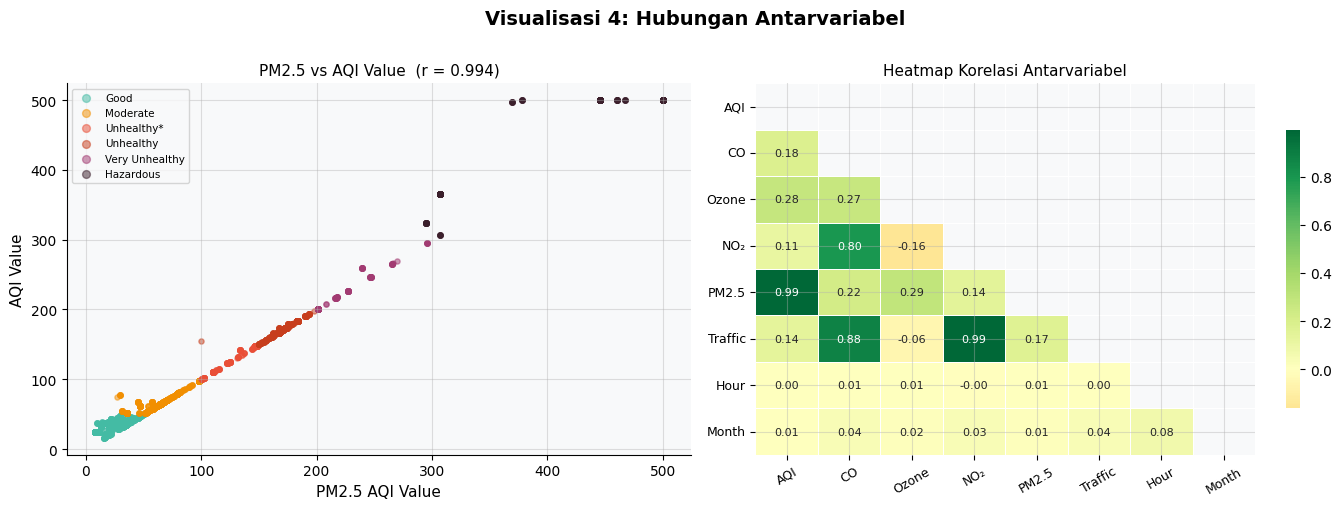

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Visualisasi 4: Hubungan Antarvariabel', fontsize=14, fontweight='bold', y=1.01)

# Scatter PM2.5 vs AQI
ax1 = axes[0]
sample = df.sample(min(3000, len(df)), random_state=42)
cat_colors = {'Good':'#44BBA4', 'Moderate':'#F18F01',
              'Unhealthy for Sensitive Groups':'#E94F37',
              'Unhealthy':'#C73E1D', 'Very Unhealthy':'#A23B72', 'Hazardous':'#3B1F2B'}
for cat, color in cat_colors.items():
    mask = sample['AQI Category'] == cat
    ax1.scatter(sample.loc[mask,'PM2.5 AQI Value'], sample.loc[mask,'AQI Value'],
                color=color, alpha=0.5, s=14, label=cat.replace(' for Sensitive Groups','*'))
r, _ = stats.pearsonr(df['PM2.5 AQI Value'], df['AQI Value'])
ax1.set_xlabel('PM2.5 AQI Value', fontsize=11)
ax1.set_ylabel('AQI Value', fontsize=11)
ax1.set_title(f'PM2.5 vs AQI Value  (r = {r:.3f})', fontsize=11)
ax1.legend(fontsize=7.5, markerscale=1.5)

# Heatmap korelasi
ax2 = axes[1]
corr_cols   = ['AQI Value','CO AQI Value','Ozone AQI Value','NO2 AQI Value',
               'PM2.5 AQI Value','traffic_pollution_proxy','hour','month']
corr_labels = ['AQI','CO','Ozone','NO₂','PM2.5','Traffic','Hour','Month']
corr_matrix = df[corr_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, ax=ax2, mask=mask, annot=True, fmt='.2f',
            xticklabels=corr_labels, yticklabels=corr_labels,
            cmap='RdYlGn', center=0, linewidths=0.5, annot_kws={'size': 8},
            cbar_kws={'shrink': 0.75})
ax2.set_title('Heatmap Korelasi Antarvariabel', fontsize=11)
ax2.tick_params(axis='x', rotation=30, labelsize=9)
ax2.tick_params(axis='y', rotation=0, labelsize=9)

plt.tight_layout()
plt.savefig('vis4_hubungan_variabel.png', dpi=150, bbox_inches='tight')
plt.show()

**INTERPRETASI VISUALISASI 4:**
   
Scatter plot memperlihatkan hubungan linear sempurna antara PM2.5 AQI dan AQI Value dengan nilai r = 0.994, p < 0.001. Heatmap korelasi memperkuat temuan selain PM2.5, tidak ada variabel lain yang berkorelasi kuat dengan AQI yaitu traffic_proxy r=0.14, hour r=0.004. Implikasi model prediktif AQI harus memprioritaskan PM2.5 sebagai fitur utama.

**Visualisasi 5: Distribusi Polutan & Traffic Proxy**

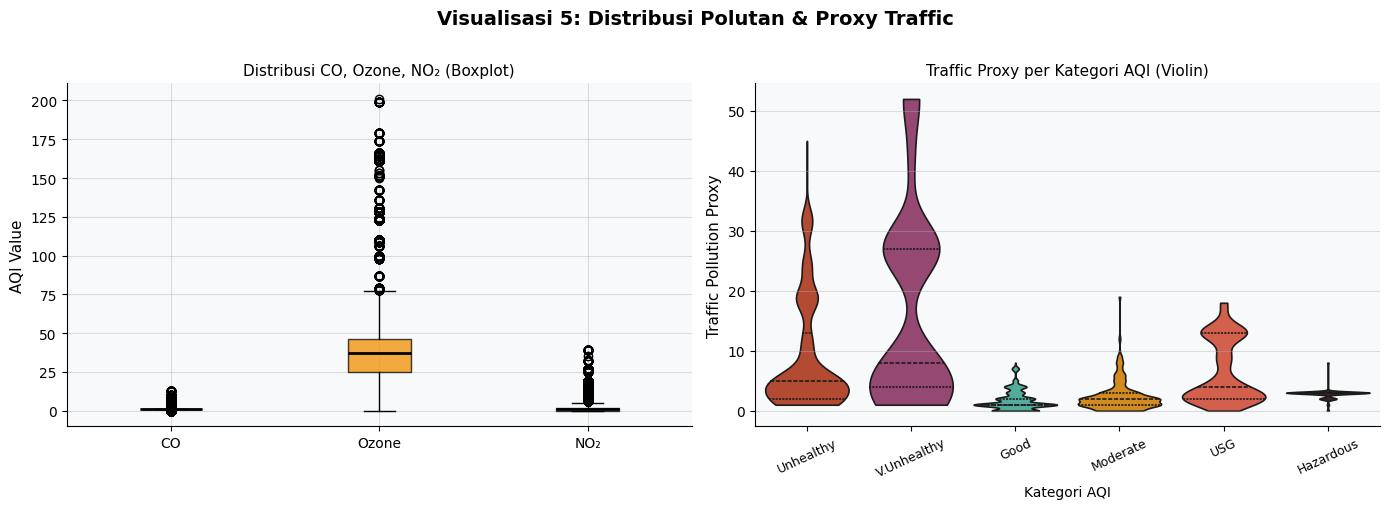

In [35]:
cat_order_plot = ['Good','Moderate','Unhealthy for Sensitive Groups',
                  'Unhealthy','Very Unhealthy','Hazardous']
colors_pie     = ['#44BBA4','#F18F01','#E94F37','#C73E1D','#A23B72','#3B1F2B']
cat_short = {
    'Good':'Good', 'Moderate':'Moderate',
    'Unhealthy for Sensitive Groups':'USG',
    'Unhealthy':'Unhealthy', 'Very Unhealthy':'V.Unhealthy', 'Hazardous':'Hazardous'
}
order_short = ['Good','Moderate','USG','Unhealthy','V.Unhealthy','Hazardous']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Visualisasi 5: Distribusi Polutan & Proxy Traffic',
             fontsize=14, fontweight='bold', y=1.01)

# Boxplot polutan minor
ax1 = axes[0]
data_bp = [df['CO AQI Value'], df['Ozone AQI Value'], df['NO2 AQI Value']]
bp = ax1.boxplot(data_bp, tick_labels=['CO','Ozone','NO₂'],
                  patch_artist=True, notch=False,
                  medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], ['#2E86AB','#F18F01','#44BBA4']):
    patch.set_facecolor(color); patch.set_alpha(0.75)
ax1.set_ylabel('AQI Value', fontsize=11)
ax1.set_title('Distribusi CO, Ozone, NO₂ (Boxplot)', fontsize=11)

# Violin plot traffic proxy per kategori
ax2 = axes[1]
df_v = df[df['AQI Category'].isin(cat_order_plot)].copy()
df_v['Cat_Short'] = df_v['AQI Category'].map(cat_short)
sns.violinplot(data=df_v, x='Cat_Short', y='traffic_pollution_proxy',
               hue='Cat_Short', hue_order=order_short, palette=dict(zip(order_short, colors_pie[:6])),
               legend=False, ax=ax2, inner='quartile', linewidth=1.2, cut=0)
ax2.set_xlabel('Kategori AQI', fontsize=10)
ax2.set_ylabel('Traffic Pollution Proxy', fontsize=11)
ax2.set_title('Traffic Proxy per Kategori AQI (Violin)', fontsize=11)
ax2.tick_params(axis='x', rotation=25, labelsize=9)

plt.tight_layout()
plt.savefig('vis5_polutan_traffic.png', dpi=150, bbox_inches='tight')
plt.show()

**INTERPRETASI VISUALISASI 5:**

Boxplot menunjukkan Ozone memiliki sebaran nilai paling lebar dan outlier paling banyak, mengindikasikan Ozone lebih berfluktuasi bergantung kondisi atmosfer. Violin plot traffic proxy memperlihatkan distribusi traffic cenderung seragam di semua kategori AQI, hal ini mengonfirmasi bahwa korelasi lemah traffic dengan AQI dengan nilai r=0.14. PM2.5 dari sumber non kendaraan seperti industri dan kebakaran hutan lebih berpengaruh dari emisi kendaraan secara langsung.

# **Ringkasan Temuan Eksploratif dan Kaitan dengan Pertanyaan Analitik**

**Temuan Eksploratif**
1. PM2.5 adalah polutan utama penentu AQI dengan nilai r=0.994. Proporsi Hazardous 12.1% mengindikasikan ancaman kesehatan yang serius
2. Pola musiman yang signifikan dengan AQI tertinggi dari Januari – Februari dan September – November dan terendah dari Juni - Agustus. Tren harian data menunjukkan relatif datar
3. Traffic proxy berkorelasi lemah dengan nilai AQI adalah r=0.14, PM2.5 didominasi sumber industri atau kebakaran, bukan emisi kendaraan

**Visualisasi Pendukung**
1. Visualisasi 1 mengenai Distribusi, Visualisasi 3 mengenai Polutan, dan Visualisasi 4 mengenai Korelasi
2. Visualisasi 2 dengan Tren Bulanan dan Per Jam
3. Visualisasi 4 dengan Scatter PM2.5 dan Visualisasi 5 dengan Violin Traffic

**Implikasi**
1. Model prediksi harus fokus pada fitur PM2.5 sebagai prediktor utama
2. Waktu/musim perlu dimasukkan sebagai fitur temporal dalam pemodelan
3. Kebijakan perlu menyasar sumber PM2.5 non kendaraan seperti industri dan kebakaran

**Pertanyaan Analitik**
1. Variabel mana yang paling signifikan memprediksi AQI Value?
PM2.5 dengan AQI Value r=0.994 adalah yang paling signifikan sebagai prediktor utama

2. Apakah ada pola temporal yang mempengaruhi kualitas udara? Ya, terdapat pola temporal. Pola musiman dari Januari – Februari dan September – November perlu dimodelkan

3. Apakah kepadatan lalu lintas berkontribusi signifikan terhadap AQI? Tidak langsung, terdapat sumber PM2.5 lain yang lebih dominan


# **Model: Analisis Lanjutan AQI Value**

Bagian ini membangun model regresi untuk menganalisis dan memprediksi **AQI Value** berdasarkan indikator polutan, fitur temporal, fitur wilayah hasil frequency encoding, dan fitur hasil integrasi dataset. Target dipilih sebagai nilai numerik AQI karena pertanyaan analitik utama menanyakan variabel yang paling signifikan dalam memprediksi kualitas udara.

Model pada bagian ini perlu dipahami sebagai **model explanatory atau analitik**, bukan sepenuhnya model prediksi operasional. Hal ini karena beberapa fitur input seperti `CO AQI Value`, `Ozone AQI Value`, `NO2 AQI Value`, dan `PM2.5 AQI Value` memiliki hubungan langsung dengan target `AQI Value`. Oleh karena itu, hasil model terutama digunakan untuk mengidentifikasi faktor dominan yang menjelaskan variasi AQI.

Model yang dibandingkan:
1. **Baseline Mean Regressor** sebagai pembanding paling sederhana.
2. **PM2.5 Only** sebagai baseline berbasis satu polutan dominan.
3. **Max Pollutant Rule** sebagai baseline rule-based berdasarkan nilai maksimum AQI polutan.
4. **Linear Regression** untuk melihat hubungan linear dan interpretasi koefisien.
5. **Random Forest Regressor** untuk menangkap pola non-linear dan interaksi antarfitur.
6. **Gradient Boosting Regressor** sebagai model ensemble bertahap yang biasanya kuat pada data tabular.

Metrik evaluasi yang digunakan adalah **MAE**, **RMSE**, dan **R²**. MAE dan RMSE mengukur besar error prediksi, sedangkan R² mengukur proporsi variasi AQI yang berhasil dijelaskan model.

## **Identifikasi Fungsi Evaluasi Model**

Karena target model berupa nilai numerik kontinu (**AQI Value**), fungsi evaluasi yang digunakan adalah metrik regresi:

- **MAE (Mean Absolute Error)**: rata-rata selisih absolut antara nilai aktual dan prediksi. Metrik ini mudah diinterpretasikan dalam satuan AQI.
- **RMSE (Root Mean Squared Error)**: memberi penalti lebih besar pada error yang ekstrem, sehingga cocok untuk mengevaluasi kegagalan model pada kondisi polusi berat.
- **R² Score**: mengukur seberapa besar variasi target yang dapat dijelaskan model. Nilai mendekati 1 menunjukkan model sangat baik.

Dalam konteks kualitas udara, RMSE penting karena kesalahan besar pada kategori AQI tinggi dapat berdampak pada rekomendasi kebijakan dan peringatan kesehatan.


In [36]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

file_id = "1pA4xQC3CJsaK-B2TS7TYkk43tiiolwZP"
url = f"https://drive.google.com/uc?id={file_id}"

output = "cleaned_dataset.csv"
gdown.download(url, output, quiet=False)

df_model = pd.read_csv(output)

unnamed_cols = [
    col for col in df_model.columns
    if str(col).startswith("Unnamed") or col == ""
]

df_model = df_model.drop(columns=unnamed_cols, errors="ignore")

print(f"Ukuran data modeling: {df_model.shape[0]:,} baris x {df_model.shape[1]} kolom")
df_model.head()

Downloading...
From: https://drive.google.com/uc?id=1pA4xQC3CJsaK-B2TS7TYkk43tiiolwZP
To: /content/cleaned_dataset.csv
100%|██████████| 3.04M/3.04M [00:00<00:00, 176MB/s]

Ukuran data modeling: 14,524 baris x 32 kolom


,country,city,AQI Value,AQI Category,CO AQI Value,Ozone AQI Value,NO2 AQI Value,PM2.5 AQI Value,value,latitude,...,PM2.5 AQI Category_Good,PM2.5 AQI Category_Hazardous,PM2.5 AQI Category_Moderate,PM2.5 AQI Category_Unhealthy,PM2.5 AQI Category_Unhealthy for Sensitive Groups,PM2.5 AQI Category_Very Unhealthy,pollutant_bc,pollutant_co,pollutant_o3,traffic_pollution_proxy
0,0.423299,0.002066,154,Unhealthy,3,100,2,154,0.837986,0.25,...,False,False,False,True,False,False,False,True,False,5
1,0.423299,0.002066,154,Unhealthy,3,100,2,154,1.047483,0.25,...,False,False,False,True,False,False,False,True,False,5
2,0.423299,0.002066,154,Unhealthy,3,100,2,154,0.305516,0.25,...,False,False,False,True,False,False,False,True,False,5
3,0.423299,0.002066,154,Unhealthy,3,100,2,154,0.899090,0.25,...,False,False,False,True,False,False,False,True,False,5
4,0.423299,0.002066,154,Unhealthy,3,100,2,154,1.178418,0.25,...,False,False,False,True,False,False,False,True,False,5


## **Seleksi Fitur Model**

Fitur yang digunakan dipilih dari variabel numerik yang tersedia setelah preprocessing. Kolom **AQI Value** digunakan sebagai target, sedangkan kolom **AQI Category** tidak digunakan karena merupakan label kategori dari target. Kolom kategori polutan hasil one-hot encoding juga tidak dijadikan fitur utama agar model tidak terlalu bergantung pada label kategori turunan.

Fitur utama yang digunakan:
- Polutan: `CO AQI Value`, `Ozone AQI Value`, `NO2 AQI Value`, `PM2.5 AQI Value`
- Fitur konsentrasi OpenAQ: `value`
- Fitur wilayah dan geospasial: `country`, `city`, `latitude`, `longitude`
- Fitur temporal: `hour`, `day_of_week`, `month`
- Fitur rekayasa: `traffic_pollution_proxy`, `averaged_over_in_hours`
- One-hot jenis polutan OpenAQ: `pollutant_bc`, `pollutant_co`, `pollutant_o3`

Perlu diperhatikan bahwa fitur `CO AQI Value`, `Ozone AQI Value`, `NO2 AQI Value`, dan `PM2.5 AQI Value` memiliki hubungan langsung dengan `AQI Value`. Akibatnya, model dapat menghasilkan performa yang sangat tinggi karena terdapat potensi **data leakage konseptual**. Dalam tugas ini, fitur-fitur tersebut tetap digunakan karena tujuan model adalah menjelaskan faktor dominan pembentuk AQI, bukan membangun sistem prediksi kualitas udara yang sepenuhnya independen dari komponen AQI.

In [37]:
target_col = 'AQI Value'

excluded_cols = [
    target_col,
    'AQI Category',
    'CO AQI Category_Good',
    'Ozone AQI Category_Good',
    'Ozone AQI Category_Moderate',
    'Ozone AQI Category_Unhealthy',
    'Ozone AQI Category_Unhealthy for Sensitive Groups',
    'Ozone AQI Category_Very Unhealthy',
    'NO2 AQI Category_Good',
    'PM2.5 AQI Category_Good',
    'PM2.5 AQI Category_Hazardous',
    'PM2.5 AQI Category_Moderate',
    'PM2.5 AQI Category_Unhealthy',
    'PM2.5 AQI Category_Unhealthy for Sensitive Groups',
    'PM2.5 AQI Category_Very Unhealthy',
]

candidate_features = [col for col in df_model.columns if col not in excluded_cols]

# Pastikan seluruh fitur dapat diproses sebagai numerik.
X = df_model[candidate_features].copy()
for col in X.columns:
    if X[col].dtype == 'bool':
        X[col] = X[col].astype(int)
    else:
        X[col] = pd.to_numeric(X[col], errors='coerce')

y = pd.to_numeric(df_model[target_col], errors='coerce')

model_data = pd.concat([X, y.rename(target_col)], axis=1).dropna()
X = model_data[candidate_features]
y = model_data[target_col]

print(f"Jumlah fitur digunakan: {X.shape[1]}")
print("Daftar fitur:")
print(X.columns.tolist())
print(f"Jumlah baris setelah drop NA: {len(X):,}")


Jumlah fitur digunakan: 17
Daftar fitur:
['country', 'city', 'CO AQI Value', 'Ozone AQI Value', 'NO2 AQI Value', 'PM2.5 AQI Value', 'value', 'latitude', 'longitude', 'averaged_over_in_hours', 'hour', 'day_of_week', 'month', 'pollutant_bc', 'pollutant_co', 'pollutant_o3', 'traffic_pollution_proxy']
Jumlah baris setelah drop NA: 14,524


## **Pembagian Dataset**

Dataset dibagi menjadi **80% data latih** dan **20% data uji**. Pembagian dilakukan dengan `random_state=42` agar hasil dapat direproduksi. Karena target berupa regresi numerik, stratifikasi tidak digunakan pada tahap ini.

Pembagian data masih menggunakan **random split**, sehingga terdapat kemungkinan data dari kota atau negara yang sama muncul pada data latih dan data uji. Hal ini dapat membuat performa model terlihat lebih tinggi daripada kemampuan generalisasi sebenarnya pada wilayah baru. Oleh karena itu, hasil evaluasi perlu dibaca sebagai evaluasi awal terhadap pola dalam dataset, bukan sebagai jaminan performa untuk semua wilayah atau periode waktu baru.

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Data latih: {X_train.shape[0]:,} baris")
print(f"Data uji  : {X_test.shape[0]:,} baris")


Data latih: 11,619 baris
Data uji  : 2,905 baris


## **Pelatihan Model**


In [39]:
models = {
    'Baseline Mean': None,
    'Linear Regression': Pipeline(steps=[
        ('scaler', StandardScaler()),
        ('model', LinearRegression())
    ]),
    'Random Forest': RandomForestRegressor(
        n_estimators=200,
        max_depth=12,
        min_samples_leaf=3,
        random_state=42,
        n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
}

results = []
predictions = {}

def add_result(name, y_pred):
    predictions[name] = y_pred
    results.append({
        'Model': name,
        'MAE': mean_absolute_error(y_test, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'R2': r2_score(y_test, y_pred)
    })

# Baseline 1: semua prediksi bernilai rata-rata target data latih.
y_pred_baseline = np.full(shape=len(y_test), fill_value=y_train.mean())
add_result('Baseline Mean', y_pred_baseline)

# Baseline 2: prediksi AQI hanya menggunakan PM2.5 AQI Value.
# Pembanding ini penting karena EDA menunjukkan PM2.5 adalah prediktor dominan.
if 'PM2.5 AQI Value' in X_test.columns:
    add_result('PM2.5 Only', X_test['PM2.5 AQI Value'].values)

# Baseline 3: pendekatan rule-based sederhana, AQI diperkirakan dari nilai maksimum polutan.
pollutant_feature_cols = [
    col for col in ['CO AQI Value', 'Ozone AQI Value', 'NO2 AQI Value', 'PM2.5 AQI Value']
    if col in X_test.columns
]
if pollutant_feature_cols:
    add_result('Max Pollutant Rule', X_test[pollutant_feature_cols].max(axis=1).values)

for name, model in models.items():
    if model is None:
        continue
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    predictions[name] = y_pred
    results.append({
        'Model': name,
        'MAE': mean_absolute_error(y_test, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'R2': r2_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results).sort_values(by='RMSE').reset_index(drop=True)
results_df[['MAE', 'RMSE', 'R2']] = results_df[['MAE', 'RMSE', 'R2']].round(4)
results_df



,Model,MAE,RMSE,R2
0,Random Forest,0.0361,0.7640,1.0000
1,Gradient Boosting,0.7979,1.3326,0.9999
2,Max Pollutant Rule,6.1432,19.0435,0.9822
3,PM2.5 Only,9.4365,20.4756,0.9794
4,Baseline Mean,104.8689,142.8844,-0.0017
5,Linear Regression,12.2214,299.9752,-3.4149


## **Evaluasi Performa Model**

Model terbaik dipilih berdasarkan **RMSE terkecil** dan **R² tertinggi** pada data uji. RMSE dijadikan acuan utama karena kesalahan besar pada prediksi AQI tinggi lebih berisiko dalam konteks pengambilan keputusan kualitas udara.


Model terbaik berdasarkan RMSE: Random Forest
             Model      MAE     RMSE      R2
     Random Forest   0.0361   0.7640  1.0000
 Gradient Boosting   0.7979   1.3326  0.9999
Max Pollutant Rule   6.1432  19.0435  0.9822
        PM2.5 Only   9.4365  20.4756  0.9794
     Baseline Mean 104.8689 142.8844 -0.0017
 Linear Regression  12.2214 299.9752 -3.4149


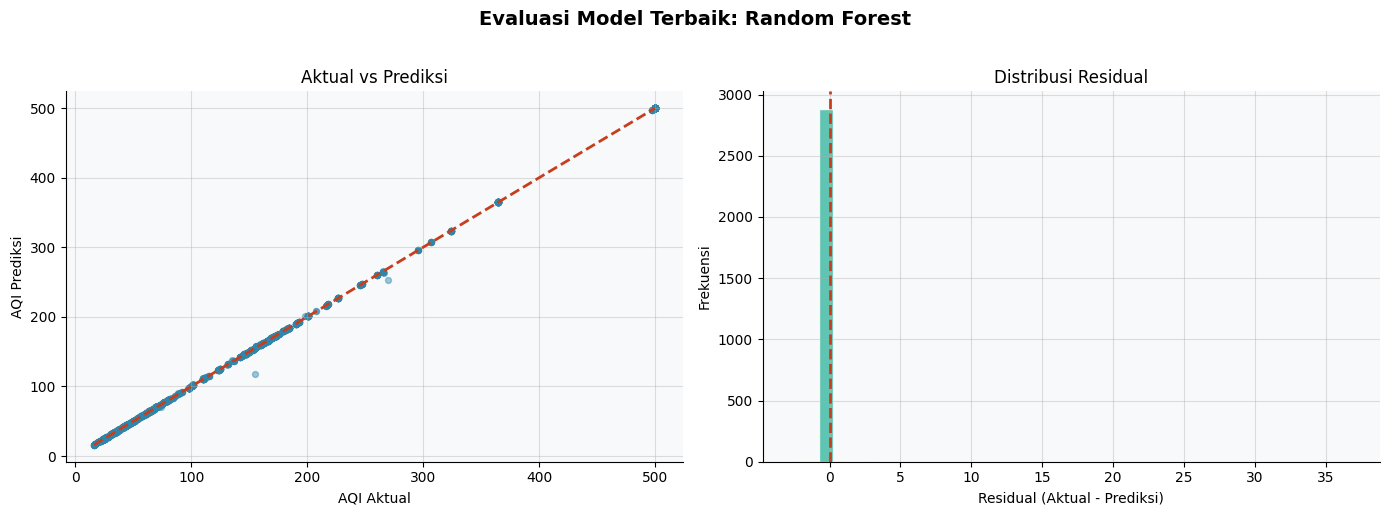

In [40]:
best_model_name = results_df.iloc[0]['Model']
best_pred = predictions[best_model_name]

print(f"Model terbaik berdasarkan RMSE: {best_model_name}")
print(results_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Evaluasi Model Terbaik: {best_model_name}', fontsize=14, fontweight='bold', y=1.02)

# Actual vs Predicted
axes[0].scatter(y_test, best_pred, alpha=0.45, s=18, color='#2E86AB')
min_val = min(y_test.min(), best_pred.min())
max_val = max(y_test.max(), best_pred.max())
axes[0].plot([min_val, max_val], [min_val, max_val], color='#C73E1D', linestyle='--', linewidth=2)
axes[0].set_xlabel('AQI Aktual')
axes[0].set_ylabel('AQI Prediksi')
axes[0].set_title('Aktual vs Prediksi')

# Residual Distribution
residuals = y_test - best_pred
axes[1].hist(residuals, bins=40, color='#44BBA4', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='#C73E1D', linestyle='--', linewidth=2)
axes[1].set_xlabel('Residual (Aktual - Prediksi)')
axes[1].set_ylabel('Frekuensi')
axes[1].set_title('Distribusi Residual')

plt.tight_layout()
plt.savefig('model_evaluation_best_model.png', dpi=150, bbox_inches='tight')
plt.show()


## **Analisis Feature Importance**

Feature importance digunakan untuk menjawab pertanyaan analitik: **variabel mana yang paling signifikan memprediksi AQI Value?**

Untuk model tree-based seperti Random Forest dan Gradient Boosting, importance dihitung dari kontribusi fitur dalam menurunkan error model. Untuk Linear Regression, interpretasi menggunakan koefisien setelah standardisasi.


,Model,Feature,Importance
0,Gradient Boosting,PM2.5 AQI Value,9.975756e-01
1,Gradient Boosting,city,8.938510e-04
2,Gradient Boosting,Ozone AQI Value,8.784501e-04
3,Gradient Boosting,longitude,4.801713e-04
4,Gradient Boosting,averaged_over_in_hours,1.279148e-04
5,Gradient Boosting,country,2.705722e-05
6,Gradient Boosting,CO AQI Value,1.438108e-05
7,Gradient Boosting,traffic_pollution_proxy,1.713184e-06
8,Gradient Boosting,latitude,4.883710e-07
9,Gradient Boosting,value,2.770775e-07


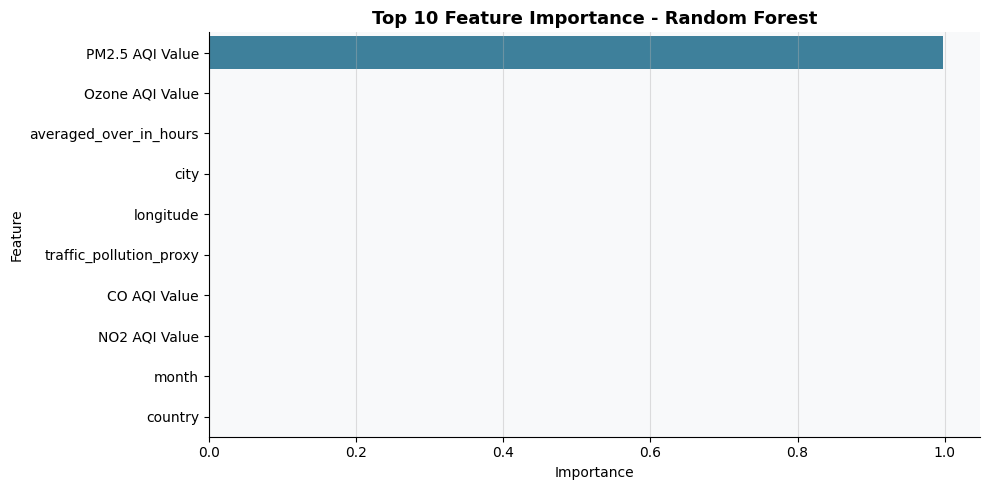

In [41]:
importance_records = []

for model_name in ['Random Forest', 'Gradient Boosting']:
    if model_name in models and hasattr(models[model_name], 'feature_importances_'):
        importances = models[model_name].feature_importances_
        for feature, importance in zip(X.columns, importances):
            importance_records.append({
                'Model': model_name,
                'Feature': feature,
                'Importance': importance
            })

importance_df = pd.DataFrame(importance_records)
if not importance_df.empty:
    top_importance = (
        importance_df
        .sort_values(['Model', 'Importance'], ascending=[True, False])
        .groupby('Model')
        .head(10)
        .reset_index(drop=True)
    )
    display(top_importance)

    rf_top = importance_df[importance_df['Model'] == 'Random Forest'].sort_values('Importance', ascending=False).head(10)
    plt.figure(figsize=(10, 5))
    sns.barplot(data=rf_top, x='Importance', y='Feature', color='#2E86AB')
    plt.title('Top 10 Feature Importance - Random Forest', fontsize=13, fontweight='bold')
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.savefig('model_feature_importance_rf.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Feature importance tidak tersedia untuk model yang dipilih.')


## **Pemilihan Model Terbaik dan Interpretasi Hasil**

Berdasarkan hasil evaluasi, model terbaik dipilih menggunakan **RMSE terkecil** dan **R² tertinggi** pada data uji. RMSE dijadikan acuan utama karena kesalahan besar pada prediksi AQI tinggi dapat berdampak pada interpretasi risiko kualitas udara.

Dari hasil model, **Random Forest** menjadi model dengan performa terbaik. Model ini mampu menghasilkan error yang sangat kecil dan nilai R² yang mendekati 1. Artinya, model dapat menjelaskan hampir seluruh variasi `AQI Value` pada data uji.

Namun, performa yang sangat tinggi perlu diinterpretasikan secara hati-hati. Hal ini disebabkan oleh penggunaan fitur AQI per polutan, seperti `PM2.5 AQI Value`, `Ozone AQI Value`, `CO AQI Value`, dan `NO2 AQI Value`, yang secara konseptual berhubungan langsung dengan `AQI Value`. Dengan demikian, model ini lebih tepat dipahami sebagai model analitik untuk menjelaskan kontributor utama AQI, bukan sebagai model prediksi operasional yang sepenuhnya independen.

Feature importance menunjukkan bahwa `PM2.5 AQI Value` menjadi fitur paling dominan dalam memprediksi `AQI Value`. Temuan ini konsisten dengan hasil eksplorasi sebelumnya, yaitu korelasi antara PM2.5 dan AQI sangat kuat. Hal ini menunjukkan bahwa variasi kualitas udara dalam dataset lebih banyak dijelaskan oleh PM2.5 dibandingkan polutan lain maupun traffic pollution proxy.

Dibandingkan baseline `PM2.5 Only` dan `Max Pollutant Rule`, model machine learning tetap memberikan peningkatan performa. Akan tetapi, peningkatan tersebut tidak mengubah kesimpulan utama bahwa PM2.5 merupakan faktor paling signifikan dalam menjelaskan nilai AQI pada dataset ini.

## **Keterbatasan Model**

1. **Potensi data leakage konseptual**  
   Fitur seperti `CO AQI Value`, `Ozone AQI Value`, `NO2 AQI Value`, dan `PM2.5 AQI Value` memiliki hubungan langsung dengan target `AQI Value`. Hal ini dapat membuat performa model terlihat sangat tinggi. Oleh karena itu, model lebih tepat digunakan untuk analisis faktor dominan pembentuk AQI, bukan sebagai sistem prediksi operasional yang sepenuhnya independen.

2. **Dominasi PM2.5**  
   `AQI Value` pada dataset sangat berkorelasi dengan `PM2.5 AQI Value`, sehingga model berpotensi terlalu bergantung pada satu fitur dominan. Akibatnya, kontribusi variabel lain seperti traffic proxy, lokasi, dan waktu dapat terlihat lebih kecil.

3. **Random split belum menguji generalisasi wilayah**  
   Pembagian data menggunakan random split memungkinkan data dari kota atau negara yang sama muncul pada data latih dan data uji. Hal ini dapat membuat evaluasi lebih optimistis dibandingkan jika model diuji pada wilayah yang benar-benar baru.

4. **Integrasi dataset berbasis kota dan negara**  
   Inner join hanya mempertahankan baris yang cocok pada kedua dataset, sehingga cakupan data akhir lebih terbatas dibanding dataset mentah. Beberapa kota atau negara yang tidak memiliki kecocokan data dapat tereliminasi dari analisis.

5. **Traffic pollution proxy bersifat tidak langsung**  
   Fitur `traffic_pollution_proxy` dibangun dari CO dan NO₂ AQI Value, bukan dari data lalu lintas aktual seperti jumlah kendaraan, kepadatan jalan, atau tingkat kemacetan. Oleh karena itu, fitur ini hanya dapat digunakan sebagai pendekatan kasar terhadap kontribusi aktivitas transportasi.

6. **Keterbatasan temporal**  
   Fitur waktu berasal dari timestamp OpenAQ, sedangkan data AQI pendukung tidak selalu memiliki resolusi waktu yang sama. Hal ini membatasi kemampuan model dalam menangkap dinamika kualitas udara secara real-time.

7. **Keterbatasan sumber data**  
   Dataset pendukung tidak selalu memiliki metodologi pengumpulan yang setransparan sumber resmi seperti OpenAQ. Karena itu, hasil model perlu dibaca sebagai analisis eksploratif berbasis dataset yang tersedia, bukan sebagai acuan resmi kualitas udara.

# **iNterpret: Insight, Rekomendasi, dan Implikasi**

Bagian ini mengubah hasil eksplorasi dan pemodelan menjadi wawasan yang dapat
ditindaklanjuti. Karena kolom `country` dan `city` telah di-*frequency-encode*
pada tahap Scrub, nama wilayah aslinya tidak lagi tersedia pada `df`. Oleh karena
itu dataset gabungan disusun ulang sambil mempertahankan nama negara dan kota untuk menjawab pertanyaan analitik mengenai perbandingan antarwilayah.

In [42]:
df_o = pd.read_csv('/content/openaq.global_air_quality.csv')
df_g = pd.read_csv('/content/pollution.csv').rename(columns={'Country': 'country'})

df_o['country_name'] = df_o['country'].map(country_code_map)
df_o['city_clean'] = df_o['city'].str.strip().str.lower()
df_g['city_clean'] = df_g['City'].str.strip().str.lower()

df_named = pd.merge(
    df_g, df_o,
    left_on=['city_clean', 'country'],
    right_on=['city_clean', 'country_name'],
    how='inner', suffixes=('_global', '_openaq')
).drop(columns=['city']).rename(columns={'country_global': 'country', 'City': 'city'})

print(f"Dataset bernama: {df_named.shape[0]:,} baris | "
      f"{df_named['country'].nunique()} negara | {df_named['city'].nunique()} kota")

Dataset bernama: 14,524 baris | 33 negara | 386 kota


## **Perbandingan Kualitas Udara Antarnegara**

Visualisasi berikut menjawab pertanyaan analitik mengenai perbedaan kondisi
kualitas udara antarwilayah. Negara dengan jumlah observasi minimal 30 disertakan
agar peringkat tidak bias oleh wilayah dengan sampel sangat kecil.

10 negara dengan rata-rata AQI tertinggi:
            mean_aqi  hazardous_pct     n
country                                  
India          242.1           28.6  6148
Peru           110.0            0.0   127
Brazil          97.3            0.0   374
Hungary         81.0            0.0    33
Austria         70.0            0.0   205
Montenegro      63.1            0.0    69
Luxembourg      63.0            0.0    87
Italy           58.1            0.0  1999
France          56.1            0.0    51
Germany         55.8            0.0    72

10 negara dengan rata-rata AQI terendah:
             mean_aqi  hazardous_pct     n
country                                   
Thailand         50.9            0.0  1210
Ireland          48.9            0.0    33
Turkey           45.2            0.0    53
Mexico           42.4            0.0   268
Lithuania        37.9            0.0    36
Spain            37.4            0.0   435
Netherlands      36.8            0.0   228
Portugal         30.2    

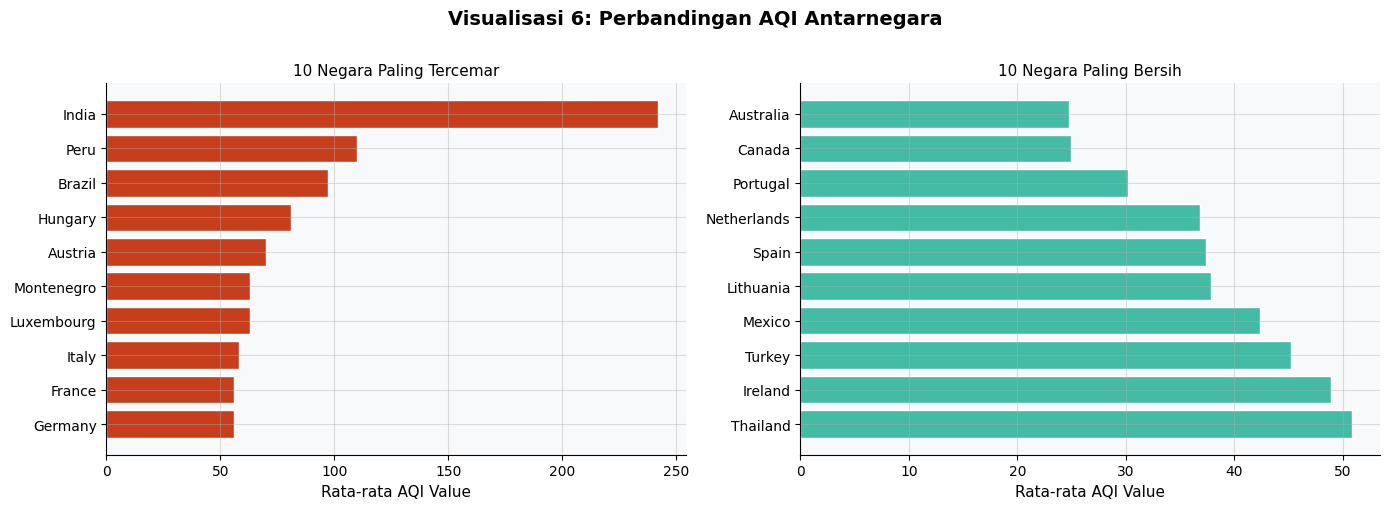

In [43]:
region = (df_named.groupby('country')
          .agg(mean_aqi=('AQI Value', 'mean'),
               hazardous_pct=('AQI Category', lambda s: (s == 'Hazardous').mean() * 100),
               n=('AQI Value', 'size'))
          .query('n >= 30')
          .sort_values('mean_aqi', ascending=False))

print("10 negara dengan rata-rata AQI tertinggi:")
print(region.head(10).round(1).to_string())
print("\n10 negara dengan rata-rata AQI terendah:")
print(region.tail(10).round(1).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Visualisasi 6: Perbandingan AQI Antarnegara', fontsize=14, fontweight='bold', y=1.01)

top10 = region.head(10).sort_values('mean_aqi')
axes[0].barh(top10.index, top10['mean_aqi'], color='#C73E1D', edgecolor='white')
axes[0].set_title('10 Negara Paling Tercemar', fontsize=11)
axes[0].set_xlabel('Rata-rata AQI Value', fontsize=11)

bot10 = region.tail(10).sort_values('mean_aqi', ascending=False)
axes[1].barh(bot10.index, bot10['mean_aqi'], color='#44BBA4', edgecolor='white')
axes[1].set_title('10 Negara Paling Bersih', fontsize=11)
axes[1].set_xlabel('Rata-rata AQI Value', fontsize=11)

plt.tight_layout()
plt.savefig('vis6_perbandingan_wilayah.png', dpi=150, bbox_inches='tight')
plt.show()

**INTERPRETASI VISUALISASI 6:**

Terdapat ketimpangan besar antarnegara. India memiliki rata-rata AQI sekitar 242.1
dari 6.148 observasi dan tergolong Very Unhealthy, jauh di atas negara lain seperti
Peru 110.0 dan Brazil 97.3. Sebaliknya Australia 24.8 dan Kanada 25.0 berada pada
kategori Good. Karena India mendominasi sebagian besar baris data, kondisinya sangat
memengaruhi rata-rata global. Temuan ini menegaskan bahwa beban pencemaran
terkonsentrasi pada wilayah tertentu sehingga prioritas penanganan tidak dapat
disamaratakan untuk seluruh wilayah.

In [44]:
print("=" * 60)
print("  BUKTI KUANTITATIF UNTUK INSIGHT & REKOMENDASI")
print("=" * 60)
print(f"Korelasi PM2.5 vs AQI       : {df_named['PM2.5 AQI Value'].corr(df_named['AQI Value']):.3f}")
traffic = df_named['CO AQI Value'] + df_named['NO2 AQI Value']
print(f"Korelasi proksi lalu lintas : {traffic.corr(df_named['AQI Value']):.3f}")
print(f"Proporsi kategori Hazardous : {(df_named['AQI Category'] == 'Hazardous').mean() * 100:.1f}%")
print(f"Negara AQI tertinggi        : {region.index[0]} ({region.iloc[0]['mean_aqi']:.1f})")
print("\nRata-rata AQI per bulan:")
print(df_named.assign(month=pd.to_datetime(df_named['timestamp']).dt.month)
      .groupby('month')['AQI Value'].mean().round(1).to_string())

  BUKTI KUANTITATIF UNTUK INSIGHT & REKOMENDASI
Korelasi PM2.5 vs AQI       : 0.994
Korelasi proksi lalu lintas : 0.135
Proporsi kategori Hazardous : 12.1%
Negara AQI tertinggi        : India (242.1)

Rata-rata AQI per bulan:
month
1     201.7
2     214.8
3     114.1
4     129.9
5     133.3
6      94.9
7     110.0
8     103.0
9     185.8
10    127.2
11    198.0
12     67.2


## **Insight Utama**

Empat insight utama dirumuskan dari keseluruhan analisis dan seluruhnya berlandaskan bukti data.

| No | Insight | Bukti Data | Implikasi |
|----|---------|-----------|-----------|
| 1 | PM2.5 merupakan penentu dominan kualitas udara | Korelasi PM2.5 terhadap AQI mencapai 0.994 dan menjadi fitur dengan *importance* tertinggi pada Random Forest | Pemantauan dan baku mutu sebaiknya menempatkan PM2.5 sebagai indikator prioritas |
| 2 | Pencemaran bersifat musiman, bukan harian | Rata-rata AQI memuncak pada Januari 201.7, Februari 214.8, dan November 198.0 sementara tren per jam relatif datar | Peringatan dini dan kebijakan perlu dijadwalkan mengikuti musim |
| 3 | Lalu lintas bukan sumber utama PM2.5 | Proksi lalu lintas hanya berkorelasi 0.135 dan sebarannya seragam di semua kategori AQI | Pengendalian diarahkan ke industri dan pembakaran, bukan hanya emisi kendaraan |
| 4 | Beban pencemaran terkonsentrasi di wilayah tertentu | India rata-rata 242.1 dari 6.148 observasi berbanding Australia 24.8 dan Kanada 25.0 | Sumber daya pengendalian diarahkan ke wilayah berbeban tinggi |

Keempat insight ini menjawab pertanyaan analitik secara langsung. Variabel paling
signifikan adalah PM2.5, pola temporal terbukti musiman, kontribusi lalu lintas
lemah, dan kondisi antarwilayah sangat timpang.

## **Rekomendasi**

Rekomendasi disusun spesifik dengan menyertakan pihak sasaran, dasar data, dan prioritas agar dapat langsung dipakai dalam pengambilan keputusan.

| No | Rekomendasi | Pihak Sasaran | Dasar Data | Prioritas |
|----|-------------|---------------|-----------|-----------|
| 1 | Menjadikan PM2.5 sebagai indikator prioritas pemantauan dan penetapan baku mutu | KLHK, Dinas Lingkungan Hidup, BMKG | Korelasi 0.994 dan *importance* tertinggi | Tinggi |
| 2 | Mengaktifkan peringatan dini musiman pada bulan puncak (Januari, Februari, September–November) | BMKG dan Dinas Kesehatan | Tren bulanan AQI | Tinggi |
| 3 | Mengarahkan pengendalian ke sumber non-kendaraan seperti industri dan pembakaran | Pemerintah Daerah dan KLHK | Proksi lalu lintas hanya 0.135 | Sedang |
| 4 | Memprioritaskan wilayah berbeban tinggi yang berada pada kategori sangat tidak sehat | Pemerintah Pusat dan Daerah | India rata-rata 242.1 dan proporsi Hazardous 12.1% | Tinggi |

## **Implikasi bagi Pengguna Sasaran**

Hasil analisis memberikan manfaat berbeda bagi tiap kelompok pengguna.

1. Pemerintah dan regulator memperoleh dasar bukti untuk menetapkan kebijakan pengendalian PM2.5 dan menyesuaikan baku mutu udara.
2. Peneliti dan akademisi memperoleh dataset terintegrasi lintas wilayah untuk studi epidemiologi dan pemodelan dampak kesehatan.
3. Organisasi kesehatan dapat merancang intervensi berbasis musim untuk melindungi kelompok rentan pada periode puncak.
4. Masyarakat kota memperoleh informasi yang mudah dipahami untuk menyesuaikan aktivitas luar ruang saat kualitas udara buruk.

## **Keterbatasan Analisis dan Pengembangan Lanjut**

1. Nilai AQI sangat ditentukan PM2.5 sehingga terdapat potensi kebocoran konsep pada model dan performa terlihat lebih tinggi daripada kemampuan generalisasi sebenarnya.
2. Integrasi dengan *inner join* membatasi cakupan menjadi 33 negara dan 386 kota sehingga sebagian wilayah tereliminasi.
3. Proksi lalu lintas dibangun dari CO dan NO₂, bukan data lalu lintas aktual, sehingga hanya pendekatan kasar.
4. Resolusi temporal bergantung pada timestamp OpenAQ sehingga dinamika *real-time* belum tertangkap.
5. Pengembangan lanjut dapat menambah data lalu lintas dan cuaca aktual, menerapkan pembagian data berbasis wilayah, serta membangun model prediksi yang independen dari komponen AQI.